# Train RQ-VAE and Assign Semantic IDs

This notebook trains the RQ-VAE on item embeddings to generate Semantic IDs.

**What this notebook does:**
1. Load item embeddings from Phase 1
2. Train the RQ-VAE (encoder, residual quantizer, decoder)
3. Assign 3-tuple Semantic IDs to all items
4. Handle collisions by appending a 4th disambiguation token
5. Save Semantic IDs and lookup tables

**Paper reference** (Section 3.1, Section 4):
> "RQ-VAE first encodes the input x via an encoder E to learn a latent representation z := E(x).
> At each level d, we have a codebook... the residual is defined as r1 := r0 - ec0.
> This process is repeated recursively m times to get a tuple of m codewords."

**Architecture** (matching paper):
- Encoder: [768, 512, 256, 128, 32] with ReLU
- Residual Quantizer: 3 levels, codebook size 256, dim 32
- Decoder: [32, 128, 256, 512, 768]

**Deviations from paper** (see Section 2 for details):
- Cosine similarity reconstruction loss instead of MSE
- AdamW optimizer (lr=3e-4) instead of Adagrad (lr=0.4)

In [1]:
%cd ..

/Users/milistu/Dev/generative-recommender


In [2]:
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from tiger.rqvae import RQVAE, UsageTracker
from tiger.utils import get_device, set_seed

In [3]:
# Paths
DATA_DIR = Path("data/2014/processed")
OUTPUT_DIR = Path("checkpoints/rqvae")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# RQ-VAE architecture (matching paper Section 4)
INPUT_DIM = 768  # Sentence-T5 embedding dimension
HIDDEN_DIMS = [512, 256, 128]  # Encoder layers (decoder mirrors this)
LATENT_DIM = 32  # Bottleneck dimension
NUM_QUANTIZERS = 3  # Number of residual quantization levels
CODEBOOK_SIZE = 256  # Entries per codebook level
COMMITMENT_WEIGHT = 0.25  # Beta from paper

# Training hyperparameters
BATCH_SIZE = 1024
NUM_ITERATIONS = 20_000
LEARNING_RATE = 3e-4  # Paper uses Adagrad lr=0.4, see note below
USAGE_THRESHOLD = 0.8  # Target codebook usage (normalized entropy)
LOG_EVERY = 50
SEED = 42

In [4]:
set_seed(SEED)
device = get_device()

2026-03-27 15:59:43.399 | INFO     | tiger.utils:set_seed:27 - Random seed set to 42
2026-03-27 15:59:43.411 | INFO     | tiger.utils:get_device:16 - Using device: mps


## 1. Load Embeddings

Load the 768-dim Sentence-T5 embeddings from Phase 1. These are the input to the RQ-VAE.

Note: Sentence-T5 outputs float16 tensors. We cast to float32 for training
compatibility (MPS crashes on dtype mismatches in matrix multiplication).

In [5]:
embeddings_dict = torch.load(DATA_DIR / "embeddings.pt", weights_only=False)

# Separate ASINs and embedding tensors, keeping a consistent order
asins = list(embeddings_dict.keys())
embedding_matrix = torch.stack([embeddings_dict[asin] for asin in asins]).float()

print(f"Items: {len(asins):,}")
print(f"Embedding matrix: {embedding_matrix.shape}")
print(f"Dtype: {embedding_matrix.dtype}")

Items: 11,924
Embedding matrix: torch.Size([11924, 768])
Dtype: torch.float32


## 2. Initialize Model and DataLoader

The architecture matches the paper exactly: encoder [768, 512, 256, 128, 32],
3-level residual quantizer with codebook size 256, and a symmetric decoder.

**Deviations from paper (with justification):**

**Optimizer:** We use AdamW (lr=3e-4) instead of the paper's Adagrad (lr=0.4).
Adagrad with lr=0.4 caused training instability on MPS (Apple Silicon). AdamW at a
standard learning rate converges reliably.

**Reconstruction loss:** We use **cosine similarity loss** (`1 - cos_sim(x, x_recon)`)
instead of the paper's MSE (`||x - x_hat||^2`). This works better because Sentence-T5
embeddings are roughly normalized. They carry semantic information primarily in their
**direction**, not magnitude. MSE spends most of its capacity matching magnitudes rather
than learning meaningful codebook assignments. Cosine loss directly optimizes for
directional alignment, which is what matters for semantic similarity.

Empirically, cosine loss achieves:
- Faster convergence to high codebook usage (all levels > 80% by step ~3,000 vs ~10,000 with MSE)
- More balanced usage across quantizer levels (Level 0 is not starved)

**Codebook lookup** still uses L2 distance (`use_cosine_sim=False`), matching the paper.

In [6]:
model = RQVAE(
    input_dim=INPUT_DIM,
    hidden_dims=HIDDEN_DIMS,
    latent_dim=LATENT_DIM,
    num_quantizers=NUM_QUANTIZERS,
    codebook_size=CODEBOOK_SIZE,
    use_cosine_sim=False,
    kmeans_init=True,
    kmeans_iters=10,
    commitment_weight=COMMITMENT_WEIGHT,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

tracker = UsageTracker(
    num_quantizers=NUM_QUANTIZERS,
    codebook_size=CODEBOOK_SIZE,
    device=device,
)

dataset = TensorDataset(embedding_matrix)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

print(f"Optimizer: AdamW (lr={LEARNING_RATE})")
print("Reconstruction loss: cosine similarity")
print(f"Batch size: {BATCH_SIZE}")
print(f"Batches per epoch: {len(dataloader)}")
print(f"Target iterations: {NUM_ITERATIONS:,}")

Model parameters: 1,124,896
Optimizer: AdamW (lr=0.0003)
Reconstruction loss: cosine similarity
Batch size: 1024
Batches per epoch: 12
Target iterations: 20,000


## 3. Train

Train for 20,000 iterations. We track codebook usage via **normalized Shannon entropy**
per quantizer level. A value of 1.0 means all codebook entries are used equally
(perfect utilization), while 0.0 means everything collapses to a single entry.

The paper targets >= 80% codebook usage:
> "The RQ-VAE model is trained for 20k epochs to ensure high codebook usage (>= 80%)." (Section 4)

In [7]:
model.train()
step = 0
best_loss = float("inf")
history = []

pbar = tqdm(total=NUM_ITERATIONS, desc="Training RQ-VAE")

while step < NUM_ITERATIONS:
    for (batch,) in dataloader:
        if step >= NUM_ITERATIONS:
            break

        batch = batch.to(device)
        x_recon, indices, recon_loss, commit_loss = model(batch)

        loss = recon_loss + commit_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tracker.update(indices)

        step += 1
        pbar.update(1)

        if step % LOG_EVERY == 0:
            usage = tracker.get_usage()
            history.append(
                {
                    "step": step,
                    "loss": loss.item(),
                    "recon_loss": recon_loss.item(),
                    "commit_loss": commit_loss.item(),
                    **{f"usage_level_{i}": u for i, u in enumerate(usage)},
                }
            )
            usage_str = " ".join(f"L{i}={u:.1%}" for i, u in enumerate(usage))
            pbar.set_postfix(
                loss=f"{loss.item():.4f}",
                recon=f"{recon_loss.item():.4f}",
                usage=usage_str,
            )

            if loss.item() < best_loss:
                best_loss = loss.item()
                torch.save(model.state_dict(), OUTPUT_DIR / "rqvae_best.pt")

pbar.close()

final_usage = tracker.get_usage()
print(f"\nTraining complete. Best loss: {best_loss:.4f}")
print(
    f"Final codebook usage: {' '.join(f'L{i}={u:.1%}' for i, u in enumerate(final_usage))}"
)
print(
    f"All levels >= {USAGE_THRESHOLD:.0%}? {all(u >= USAGE_THRESHOLD for u in final_usage)}"
)
print(f"Model saved to: {OUTPUT_DIR / 'rqvae_best.pt'}")

Training RQ-VAE:   0%|          | 0/20000 [00:00<?, ?it/s]

Training RQ-VAE: 100%|██████████| 20000/20000 [05:02<00:00, 66.19it/s, loss=0.0434, recon=0.0422, usage=L0=98.4% L1=99.7% L2=100.0%]


Training complete. Best loss: 0.0413
Final codebook usage: L0=98.4% L1=99.7% L2=100.0%
All levels >= 80%? True
Model saved to: checkpoints/rqvae/rqvae_best.pt


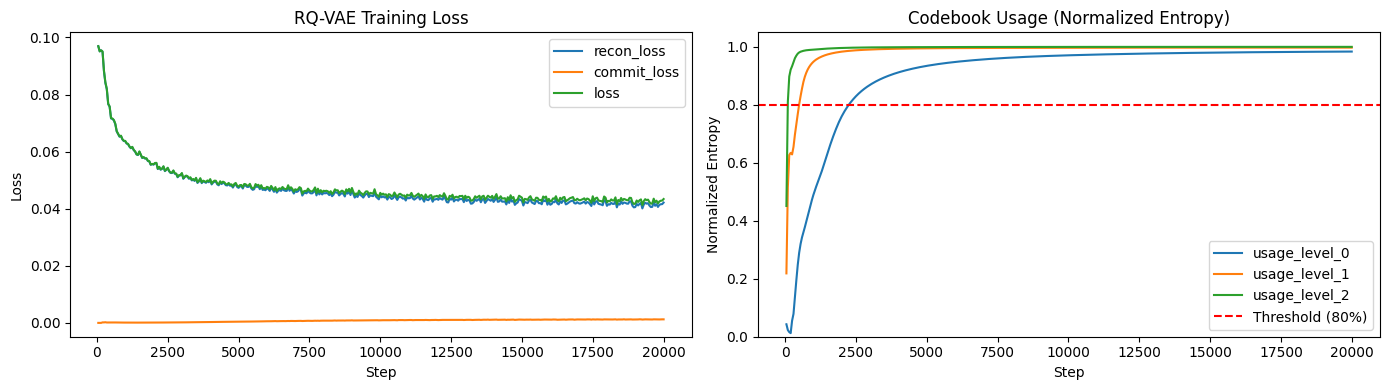

In [8]:
df_history = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
df_history.plot(x="step", y=["recon_loss", "commit_loss", "loss"], ax=ax1)
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.set_title("RQ-VAE Training Loss")

# Codebook usage
usage_cols = [c for c in df_history.columns if c.startswith("usage_")]
df_history.plot(x="step", y=usage_cols, ax=ax2)
ax2.axhline(
    y=USAGE_THRESHOLD,
    color="r",
    linestyle="--",
    label=f"Threshold ({USAGE_THRESHOLD:.0%})",
)
ax2.set_xlabel("Step")
ax2.set_ylabel("Normalized Entropy")
ax2.set_title("Codebook Usage (Normalized Entropy)")
ax2.set_ylim(0, 1.05)
ax2.legend()

fig.tight_layout()

## 4. Assign Semantic IDs

Run the trained encoder + quantizer on all item embeddings to get 3-tuple Semantic IDs.

Each item gets a tuple like `(c0, c1, c2)` where each `ci` is in `[0, 255]`.

In [9]:
model.load_state_dict(torch.load(OUTPUT_DIR / "rqvae_best.pt", weights_only=True))
model.eval()
print("Loaded best model")

Loaded best model


In [10]:
all_indices = model.get_semantic_ids(embedding_matrix.to(device))
all_indices = all_indices.cpu()

print(f"Semantic IDs shape: {all_indices.shape}")
print("Example IDs (first 5):")
for i in range(5):
    sid = tuple(all_indices[i].tolist())
    print(f"  {asins[i]} -> {sid}")

Semantic IDs shape: torch.Size([11924, 3])
Example IDs (first 5):
  0439893577 -> (50, 106, 25)
  048645195X -> (42, 187, 18)
  0545496470 -> (163, 222, 208)
  0615444172 -> (97, 174, 226)
  0670010936 -> (81, 212, 246)


## 5. Handle Collisions

Multiple items can map to the same 3-tuple Semantic ID. The paper handles this by
appending a 4th disambiguation token:

> "If two items share the Semantic ID (12, 24, 52), we append additional tokens to
> differentiate them, representing the two items as (12, 24, 52, 0) and (12, 24, 52, 1)."
> (Section 3.1)

Items without collisions get `0` as their 4th token.

In [11]:
# Group items by their 3-tuple Semantic ID
sid_to_items: dict[tuple, list[str]] = {}
for asin, indices in zip(asins, all_indices):
    sid_3 = tuple(indices.tolist())
    sid_to_items.setdefault(sid_3, []).append(asin)

# Count collisions
collision_sizes = Counter(len(v) for v in sid_to_items.values())
num_colliding = sum(count for size, count in collision_sizes.items() if size > 1)
print(f"Unique 3-tuple IDs: {len(sid_to_items):,}")
print(f"IDs with collisions: {num_colliding:,}")
print(f"Collision distribution: {dict(sorted(collision_sizes.items()))}")

Unique 3-tuple IDs: 11,530
IDs with collisions: 307
Collision distribution: {1: 11223, 2: 250, 3: 37, 4: 13, 5: 5, 6: 1, 7: 1}


In [12]:
# Build final 4-tuple Semantic IDs with disambiguation token
asin_to_sid: dict[str, tuple[int, ...]] = {}
sid_to_asin: dict[tuple[int, ...], str] = {}

for sid_3, items in sid_to_items.items():
    for idx, asin in enumerate(items):
        sid_4 = sid_3 + (idx,)
        asin_to_sid[asin] = sid_4
        sid_to_asin[sid_4] = asin

print(f"Total items with 4-tuple IDs: {len(asin_to_sid):,}")
print("\nExamples:")
for asin in list(asins)[:5]:
    print(f"  {asin} -> {asin_to_sid[asin]}")

# Verify bijection
assert len(asin_to_sid) == len(sid_to_asin) == len(asins)
print(f"\nLookup tables verified: {len(asin_to_sid):,} items, bijective mapping")

Total items with 4-tuple IDs: 11,924

Examples:
  0439893577 -> (50, 106, 25, 0)
  048645195X -> (42, 187, 18, 0)
  0545496470 -> (163, 222, 208, 0)
  0615444172 -> (97, 174, 226, 0)
  0670010936 -> (81, 212, 246, 0)

Lookup tables verified: 11,924 items, bijective mapping


## 6. Save

Save the trained model, Semantic IDs, and lookup tables for Phase 3 (seq2seq training).

In [13]:
torch.save(
    {
        "asin_to_sid": asin_to_sid,
        "sid_to_asin": sid_to_asin,
    },
    OUTPUT_DIR / "semantic_ids.pt",
)
print(f"Saved semantic IDs to {OUTPUT_DIR / 'semantic_ids.pt'}")

pd.DataFrame(history).to_csv(OUTPUT_DIR / "training_history.csv", index=False)
print(f"Saved training history to {OUTPUT_DIR / 'training_history.csv'}")

Saved semantic IDs to checkpoints/rqvae/semantic_ids.pt
Saved training history to checkpoints/rqvae/training_history.csv


In [14]:
print("=" * 50)
print("RQ-VAE TRAINING COMPLETE")
print("=" * 50)
print(f"Items:              {len(asin_to_sid):,}")
print(f"Unique 3-tuple IDs: {len(sid_to_items):,}")
print(f"Collisions:         {num_colliding:,} IDs shared by multiple items")
print("Final ID length:    4 (3 RQ-VAE levels + 1 disambiguation)")
print(f"Codebook size:      {CODEBOOK_SIZE} per level")
print(f"Best loss:          {best_loss:.4f}")
print(f"\nSaved to: {OUTPUT_DIR}/")
print("  rqvae_best.pt        -- trained model weights")
print("  semantic_ids.pt      -- asin<->sid lookup tables")
print("  training_history.csv -- loss curve")

RQ-VAE TRAINING COMPLETE
Items:              11,924
Unique 3-tuple IDs: 11,530
Collisions:         307 IDs shared by multiple items
Final ID length:    4 (3 RQ-VAE levels + 1 disambiguation)
Codebook size:      256 per level
Best loss:          0.0413

Saved to: checkpoints/rqvae/
  rqvae_best.pt        -- trained model weights
  semantic_ids.pt      -- asin<->sid lookup tables
  training_history.csv -- loss curve


## 7. Evaluate Semantic ID Quality

How good are the Semantic IDs? We evaluate three aspects:

**7a. Qualitative inspection**: Do items sharing the same or similar Semantic IDs
actually look similar? We inspect collisions (exact same 3-tuple) and prefix neighbors
(same first codeword).

**7b. Reconstruction quality**: How much information is lost during quantization?
Measured by cosine similarity between the original embedding and the reconstructed
embedding after encode -> quantize -> decode.

**7c. Hierarchical coherence**: The key property of RQ-VAE Semantic IDs is that they
form a hierarchy. Items sharing the first codeword (c0) should be more similar than
random items. Items sharing (c0, c1) should be even more similar. We measure average
pairwise cosine similarity at each prefix level.

This last metric is the most useful for comparing RQ-VAE variants (e.g., cosine vs MSE
loss, different codebook sizes) without retraining the full seq2seq model.

In [15]:
# Load item texts for qualitative inspection
items_df = pd.read_parquet(DATA_DIR / "items.parquet")
asin_to_text = dict(zip(items_df["asin"], items_df["text"]))
print(f"Loaded text for {len(asin_to_text):,} items")

Loaded text for 11,924 items


### 7a. Qualitative: Items sharing the same Semantic ID (collisions)

These items were mapped to the exact same 3-tuple. If the RQ-VAE is working well,
colliding items should be semantically very similar.

In [16]:
# Show items that collide (share the same 3-tuple Semantic ID)
collisions = {sid: items for sid, items in sid_to_items.items() if len(items) > 1}
print(f"Found {len(collisions)} colliding Semantic IDs\n")

# Show up to 5 collision groups
for sid_3, items in list(collisions.items())[:5]:
    print(f"Semantic ID: {sid_3}")
    for asin in items:
        text = asin_to_text.get(asin, "N/A")
        # Show first 120 chars of item text
        print(f"  [{asin}] {text[:120]}...")
    print()

Found 307 colliding Semantic IDs

Semantic ID: (116, 75, 167)
  [1223062341] Melissa &amp; Doug Flip to Win Hangman
Brand: Melissa &amp; Doug
Category: Toys & Games > Games > Board Games > Toys & G...
  [B000VNXSOQ] Melissa &amp; Doug Flip to Win Bingo
Brand: Melissa &amp; Doug
Category: Toys & Games > Games > Travel Games
Price: $15....
  [B000VO1CIE] Melissa &amp; Doug Flip to Win Memory Game
Brand: Melissa &amp; Doug
Category: Toys & Games > Games > Board Games
Price:...

Semantic ID: (1, 62, 193)
  [1589780817] Unhappy Homes (Gloom)
In the Gloom card game, you make your eccentric family of misfits suffer the greatest tragedies po...
  [1589781066] Unfortunate Expeditions (Gloom)
In the Gloom card game, you make your eccentric family of misfits suffer the greatest tr...

Semantic ID: (202, 15, 20)
  [1593953534] All About Me Lock &amp; Key Diary
Diaries are for dreaming! Childen love a locked book where they can record their priva...
  [B000TTOCH4] Peaceable Kingdom / Sweet Kitty Lo

### 7a (cont). Qualitative: Items sharing the same prefix

Items sharing the first codeword (c0) should belong to the same broad category.
Items sharing (c0, c1) should be even more similar, same sub-category.
This is the hierarchical property that makes RQ-VAE Semantic IDs useful.

In [17]:
# Group items by first codeword (c0) — coarse clusters
c0_groups: dict[int, list[str]] = {}
for asin, indices in zip(asins, all_indices):
    c0 = indices[0].item()
    c0_groups.setdefault(c0, []).append(asin)

# Pick a few c0 groups and show samples
print("=== Items sharing the same FIRST codeword (coarse category) ===\n")
# Pick groups with reasonable sizes
interesting_c0 = [c0 for c0, items in c0_groups.items() if 10 <= len(items) <= 100][:3]
for c0 in interesting_c0:
    items = c0_groups[c0]
    print(f"c0 = {c0} ({len(items)} items). Sample:")
    for asin in items[:5]:
        text = asin_to_text.get(asin, "N/A")
        print(f"  [{asin}] {text[:100]}...")
    print()

=== Items sharing the same FIRST codeword (coarse category) ===

c0 = 50 (79 items). Sample:
  [0439893577] Little Red Tool Box: Magnetic Tabletop Learning Easel
The Magnetic Tabletop Learning Easel is one of...
  [074242720X] Ideal School Supply Tactile Letters Kit
Grade K-1. Includes both sets of lowercase and uppercase tac...
  [1589473221] Workbooks-Math Readiness Grades K-1
SCHOOL ZONE-Workbook. This book is packed full of different acti...
  [1892069725] MindWare Subtraction Secrets
This unique math series challenges kids to improve their math skills by...
  [B00000JH41] LEARNING RESOURCES BIG TIME STUDENT CLOCK (12 HR)
A great way to help kids grasp time-telling skills...

c0 = 42 (40 items). Sample:
  [048645195X] Dover Publications-Decorative Tile Designs Coloring Book
Brand: Dover Pubns
Category: Toys & Games >...
  [1581170769] What Makes a Rainbow?: A Magic Ribbon Book
A rainbow of ribbons magically appear when you open the p...
  [B0006OFXSE] Princess Book Activity Book
Bo

In [18]:
# Drill down: items sharing (c0, c1) — finer clusters within a c0 group
print("=== Items sharing the same FIRST TWO codewords (sub-category) ===\n")

c0_example = interesting_c0[0] if interesting_c0 else list(c0_groups.keys())[0]
c01_groups: dict[tuple, list[str]] = {}
for asin, indices in zip(asins, all_indices):
    if indices[0].item() == c0_example:
        c01 = (indices[0].item(), indices[1].item())
        c01_groups.setdefault(c01, []).append(asin)

interesting_c01 = [k for k, v in c01_groups.items() if len(v) >= 3][:3]
for c01 in interesting_c01:
    items = c01_groups[c01]
    print(f"(c0, c1) = {c01} ({len(items)} items):")
    for asin in items[:4]:
        text = asin_to_text.get(asin, "N/A")
        print(f"  [{asin}] {text[:100]}...")
    print()

=== Items sharing the same FIRST TWO codewords (sub-category) ===

(c0, c1) = (50, 249) (3 items):
  [074242720X] Ideal School Supply Tactile Letters Kit
Grade K-1. Includes both sets of lowercase and uppercase tac...
  [1892069725] MindWare Subtraction Secrets
This unique math series challenges kids to improve their math skills by...
  [B00004WKR7] Learning Resources Jumbo Magnetic Uppercase Letters (40-Piece)
Big and bright--the perfect start to ...

(c0, c1) = (50, 148) (4 items):
  [B00009XNSS] Learning Resources Counting Cookies
Learning to count and recognize numbers is a treat with these co...
  [B0008FUDBI] Learning Resources Smart Snacks Gingerbread Sort and Snap
Adorable plastic cookies provide multiple ...
  [B000NG8ZXA] Learning Resources Smart Snacks Hide n Peek Chocolates
Shapes and colors hide inside this sweetheart...
  [B0034IX82M] Learning Resources Goodie Games Abc Cookies
Goodie Games ABC Cookies. Who can resist these goodies. ...

(c0, c1) = (50, 92) (5 items):
  [

### 7b. Reconstruction Quality

How much semantic information survives the bottleneck? We pass all embeddings through
encode -> quantize -> decode and measure cosine similarity with the originals.

Perfect reconstruction = 1.0. Values above 0.9 indicate the quantized representation
preserves most of the semantic content.

Reconstruction cosine similarity:
  Mean:   0.9588
  Median: 0.9600
  Min:    0.8801
  Std:    0.0155
  % > 0.9: 100.0%
  % > 0.95: 72.8%


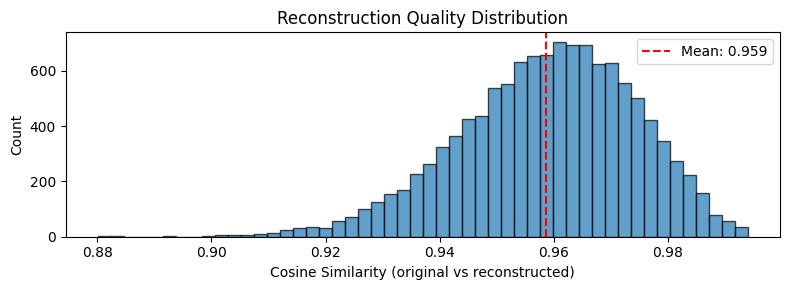

In [19]:
import torch.nn.functional as F

with torch.no_grad():
    x = embedding_matrix.to(device)
    x_recon, _, _, _ = model(x)

    # Cosine similarity per item
    cos_sims = F.cosine_similarity(x, x_recon, dim=1).cpu()

print("Reconstruction cosine similarity:")
print(f"  Mean:   {cos_sims.mean():.4f}")
print(f"  Median: {cos_sims.median():.4f}")
print(f"  Min:    {cos_sims.min():.4f}")
print(f"  Std:    {cos_sims.std():.4f}")
print(f"  % > 0.9: {(cos_sims > 0.9).float().mean():.1%}")
print(f"  % > 0.95: {(cos_sims > 0.95).float().mean():.1%}")

# Histogram
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(cos_sims.numpy(), bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Cosine Similarity (original vs reconstructed)")
ax.set_ylabel("Count")
ax.set_title("Reconstruction Quality Distribution")
ax.axvline(
    x=cos_sims.mean(), color="r", linestyle="--", label=f"Mean: {cos_sims.mean():.3f}"
)
ax.legend()
fig.tight_layout()

### 7c. Hierarchical Coherence

The most important property: do Semantic ID prefixes capture semantic similarity?

We measure the average pairwise cosine similarity of original embeddings for items
grouped by shared prefixes at each level:
- **Random pairs**: baseline, how similar are two random items?
- **Same c0**: items sharing the first codeword (coarse cluster)
- **Same (c0, c1)**: items sharing first two codewords (fine cluster)
- **Same (c0, c1, c2)**: items with identical 3-tuple (collisions)

A good RQ-VAE should show: random << same c0 < same (c0,c1) < same (c0,c1,c2).

This metric can be used to compare different RQ-VAE configurations without
retraining the full seq2seq model.

In [20]:
import numpy as np


def avg_pairwise_cosine_sim(embeddings: torch.Tensor, max_pairs: int = 5000) -> float:
    """Average pairwise cosine similarity for a set of embeddings.

    Samples pairs if the group is large to keep computation fast.
    """
    n = len(embeddings)
    if n < 2:
        return float("nan")

    # Normalize for cosine similarity
    normed = F.normalize(embeddings, dim=1)

    if n <= 200:
        # Small group: compute full similarity matrix
        sim_matrix = normed @ normed.T
        # Take upper triangle (excluding diagonal)
        mask = torch.triu(torch.ones(n, n, dtype=torch.bool), diagonal=1)
        return sim_matrix[mask].mean().item()
    else:
        # Large group: sample random pairs
        idx1 = torch.randint(0, n, (max_pairs,))
        idx2 = torch.randint(0, n, (max_pairs,))
        # Ensure different indices
        valid = idx1 != idx2
        idx1, idx2 = idx1[valid], idx2[valid]
        return (normed[idx1] * normed[idx2]).sum(dim=1).mean().item()


# Build prefix groups at each level
asin_to_idx = {asin: i for i, asin in enumerate(asins)}

results = {}

# Random baseline
rand_idx = torch.randint(0, len(asins), (10000, 2))
normed_all = F.normalize(embedding_matrix, dim=1)
rand_sim = (
    (normed_all[rand_idx[:, 0]] * normed_all[rand_idx[:, 1]]).sum(dim=1).mean().item()
)
results["Random pairs"] = rand_sim

# Same c0
c0_sims = []
for c0, items in c0_groups.items():
    if len(items) >= 2:
        idxs = [asin_to_idx[a] for a in items]
        c0_sims.append(avg_pairwise_cosine_sim(embedding_matrix[idxs]))
results["Same c0"] = np.nanmean(c0_sims)

# Same (c0, c1)
c01_all_groups: dict[tuple, list[str]] = {}
for asin, indices in zip(asins, all_indices):
    key = (indices[0].item(), indices[1].item())
    c01_all_groups.setdefault(key, []).append(asin)

c01_sims = []
for key, items in c01_all_groups.items():
    if len(items) >= 2:
        idxs = [asin_to_idx[a] for a in items]
        c01_sims.append(avg_pairwise_cosine_sim(embedding_matrix[idxs]))
results["Same (c0, c1)"] = np.nanmean(c01_sims)

# Same (c0, c1, c2) — collisions only
c012_sims = []
for sid_3, items in sid_to_items.items():
    if len(items) >= 2:
        idxs = [asin_to_idx[a] for a in items]
        c012_sims.append(avg_pairwise_cosine_sim(embedding_matrix[idxs]))
results["Same (c0, c1, c2)"] = np.nanmean(c012_sims) if c012_sims else float("nan")

# Display results
print("Hierarchical Coherence (avg pairwise cosine similarity):")
print("-" * 50)
for level, sim in results.items():
    bar = "#" * int(sim * 50) if not np.isnan(sim) else "N/A"
    print(f"  {level:<20s}: {sim:.4f}  {bar}")
print()
print("Expected pattern: Random << Same c0 < Same (c0,c1) < Same (c0,c1,c2)")

Hierarchical Coherence (avg pairwise cosine similarity):
--------------------------------------------------
  Random pairs        : 0.8188  ########################################
  Same c0             : 0.8983  ############################################
  Same (c0, c1)       : 0.9367  ##############################################
  Same (c0, c1, c2)   : 0.9798  ################################################

Expected pattern: Random << Same c0 < Same (c0,c1) < Same (c0,c1,c2)
